In [2]:
import os
import sys
import kagglehub
from pathlib  import Path
import cv2
import xml.etree.ElementTree as ET

In [2]:
os.getcwd()

'c:\\Users\\vital\\learning\\learning\\programing\\portfolio_projects\\1_image\\exploritary'

In [ ]:
curr_cwd = os.getcwd()
new_cwd = os.path.join(curr_cwd, '..')
os.chdir(new_cwd)


In [4]:
curr_cwd = os.getcwd()
curr_cwd

'c:\\Users\\vital\\learning\\learning\\programing\\portfolio_projects\\1_image'

KaggleApiHTTPError: 401 Client Error.

You don't have permission to access resource at URL: https://kaggle.com/competitions/uw-madison-gi-tract-image-segmentation
Please make sure you are authenticated and have accepted the competition rules which can be found at this location: https://kaggle.com/competitions/uw-madison-gi-tract-image-segmentation/rules

In [16]:
num = 0
idx = f'{num:05}'
xml_path = Path(output_dir,'dataset-master', 'dataset-master','Annotations',f'BloodImage_{idx}.xml')
tree = ET.parse(xml_path)


In [18]:
root = tree.getroot()

In [24]:
for child in root:
    print(child.tag, child.items)

folder <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC13F0>
filename <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC1440>
path <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC1490>
source <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC14E0>
size <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC1580>
segmented <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC16C0>
object <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC1710>
object <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC1A30>
object <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC1D50>
object <built-in method items of xml.etree.ElementTree.Element object at 0x000001BFA3CC2070>
object <built-in method items of xml.etree.ElementTree.Element object

In [6]:
zip_path = Path('data', 'uw-madison-gi-tract-image-segmentation.zip')
extr_data = Path('data', 'extracted_data')
os.makedirs(extr_data, exist_ok= True)
import zipfile
with zipfile.ZipFile(zip_path) as ziped:
    ziped.extractall(extr_data)

In [7]:
import numpy as np
img_path = Path(extr_data, 'train', 'case123', 'case123_day22', 'scans', 'slice_0083_266_266_1.50_1.50.png')
img_16 = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
img_norm = cv2.normalize(img_16, None, alpha=0, beta = 255, norm_type=cv2.NORM_MINMAX)
img_8 = img_norm.astype(np.uint8)


In [8]:
img_shape = img_8.shape
img_len = img_shape[1]*img_shape[0]
img_len

70756

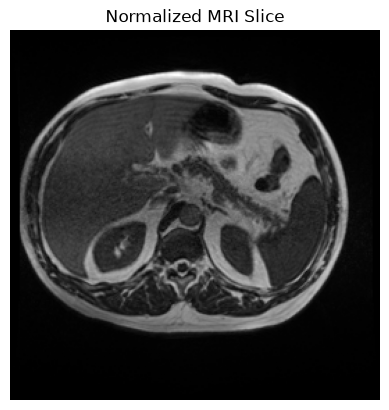

In [9]:
import matplotlib.pyplot as plt
plt.imshow(img_8, cmap='gray')
plt.title("Normalized MRI Slice")
plt.axis('off')
plt.show()

In [10]:
large_bowel_str = '22539 4 22804 6 23069 8 23334 9 23600 10 23866 10 24131 12 24397 12 24662 13 24928 14 25193 15 25459 15 25724 15 25990 15 26256 15 26522 15 26788 14 27054 14 27319 14 27584 14 27849 13 28113 14 28377 15 28642 16 28907 17 29172 18 29438 18 29703 19 29969 18 30236 17 30502 16 30769 14 31038 8'
large_bowel_arr = large_bowel_str.split()
large_bowel_nums = [int(a) for a in large_bowel_arr]
large_bowel_lens = large_bowel_nums[1::2]
large_bowel_ind = large_bowel_nums[::2]
large_bowel_flattened_mask = np.zeros(img_len)
for ind, leng in zip(large_bowel_ind, large_bowel_lens):
    large_bowel_flattened_mask[ind-1:ind+leng-1] = 1
large_bowel_mask = large_bowel_flattened_mask.reshape(img_shape)

small_bowel_str = '24627 6 24891 10 25156 12 25422 12 25688 12 25955 11 26222 9 26489 7'
small_bowel_arr = small_bowel_str.split()
small_bowel_nums = [int(a) for a in small_bowel_arr]
small_bowel_lens = small_bowel_nums[1::2]
small_bowel_ind = small_bowel_nums[::2]
small_bowel_flattened_mask = np.zeros(img_len)
for ind, leng in zip(small_bowel_ind, small_bowel_lens):
    small_bowel_flattened_mask[ind-1:ind+leng-1] = 1
small_bowel_mask = small_bowel_flattened_mask.reshape(img_shape)
  
stomach_str = '13973 10 14237 14 14502 17 14767 19 15031 23 15296 26 15561 28 15826 31 16092 32 16357 34 16622 36 16887 38 17152 39 17417 41 17683 41 17949 41 18214 42 18480 42 18746 42 19013 40 19279 40 19546 39 19813 38 20080 36 20347 35 20616 32 20886 27 21161 18 21428 16 21696 12 21964 5'
stomach_arr = stomach_str.split()
stomach_nums = [int(a) for a in stomach_arr]
stomach_lens = stomach_nums[1::2]
stomach_ind = stomach_nums[::2]
stomach_flattened_mask = np.zeros(img_len)
for ind, leng in zip(stomach_ind, stomach_lens):
    stomach_flattened_mask[ind-1:ind+leng-1] = 1
stomach_mask = stomach_flattened_mask.reshape(img_shape)

colour_img = np.stack([img_8, img_8, img_8], axis=-1)
colour_img[large_bowel_mask == 1] = [255, 0, 0]
colour_img[small_bowel_mask == 1] = [0, 255, 0]
colour_img[stomach_mask == 1] = [0, 0, 255]



In [35]:
def _one_class_mask(organ_idx_str, img_shape):
    organ_arr = organ_idx_str.split()
    organ_nums = [int(a) for a in organ_arr]
    organ_lens = organ_nums[1::2]
    organ_ind = organ_nums[::2]
    organ_flattened_mask = np.zeros(img_shape[0]*img_shape[1])
    for ind, leng in zip(organ_ind, organ_lens):
        organ_flattened_mask[ind-1:ind+leng-1] = 1
    return organ_flattened_mask.reshape(img_shape)

def make_img_mask(large_bowel_idx_str, small_bowel_idx_str, stomach_idx_str, img_shape):
    large_bowel_mask = _one_class_mask(large_bowel_idx_str, img_shape)
    small_bowel_mask = _one_class_mask(small_bowel_idx_str, img_shape)
    stomach_mask = _one_class_mask(stomach_idx_str, img_shape)
    img_mask = np.stack([large_bowel_mask, small_bowel_mask, stomach_mask], axis=-1)
    return img_mask

def _construct_id_from_path(img_path:Path):
    parts = img_path.parts
    case_and_day = parts[4]
    slice = parts[-1].split('_')[1]
    img_id = f'{case_and_day}_slice_{slice}'
    return img_id


In [13]:
import pandas as pd


In [14]:
data_map = pd.read_csv('./data/extracted_data/train.csv')

(np.float64(-0.5), np.float64(265.5), np.float64(265.5), np.float64(-0.5))

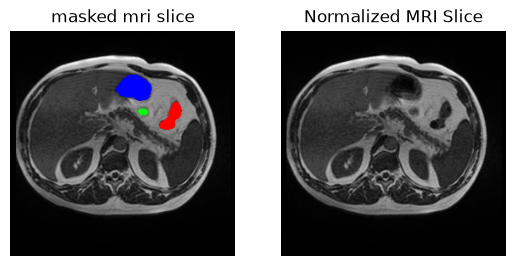

In [12]:
plt.subplot(1, 2, 1)
plt.imshow(colour_img)
plt.title("masked mri slice")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_8, cmap = 'gray')
plt.title("Normalized MRI Slice")
plt.axis('off')
#plt.show()

In [19]:
data_map[data_map['segmentation'].notna()]

,id,class,segmentation
194,case123_day20_slice_0065,stomach,28094 3 28358 7 28623 9 28889 9 29155 9 29421 ...
197,case123_day20_slice_0066,stomach,27561 8 27825 11 28090 13 28355 14 28620 15 28...
200,case123_day20_slice_0067,stomach,15323 4 15587 8 15852 10 16117 11 16383 12 166...
203,case123_day20_slice_0068,stomach,14792 5 15056 9 15321 11 15587 11 15852 13 161...
206,case123_day20_slice_0069,stomach,14526 6 14789 12 15054 14 15319 16 15584 17 15...
...,...,...,...
115459,case30_day0_slice_0135,small_bowel,22540 1 22804 5 23069 7 23334 10 23600 11 2386...
115461,case30_day0_slice_0136,large_bowel,18746 7 19009 23 19038 7 19273 44 19537 49 198...
115462,case30_day0_slice_0136,small_bowel,23079 1 23343 6 23608 9 23874 11 24139 13 2440...
115464,case30_day0_slice_0137,large_bowel,18746 2 19010 8 19040 3 19274 25 19302 12 1953...


In [39]:
type(data_map)

pandas.DataFrame

In [ ]:
def get_file_list(dir_path):
    file_list = []
    try:
        dirs = os.listdir(path = dir_path)
        for dir in dirs:
            full_path = Path(dir_path, dir)
            if os.path.isdir(full_path):
                inner_file_list = get_file_list(full_path)
                file_list += inner_file_list
            elif os.path.isfile(full_path):
                file_list.append(full_path)
        return file_list

    except PermissionError:
        print(f"Permission denied: '{dir_path}'")
        return []
    except Exception as e:
        print(f"Error: {e}")
        return []
            

In [31]:
file_list = get_file_list(Path('data', 'extracted_data', 'train'))

In [32]:
file_list

[WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0001_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0002_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0003_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0004_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0005_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0006_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0007_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0008_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/scans/slice_0009_266_266_1.50_1.50.png'),
 WindowsPath('data/extracted_data/train/case101/case101_day20/sc

In [33]:
type(file_list[0])

pathlib._local.WindowsPath

In [36]:
ids = []
for file in file_list:
    id_ = _construct_id_from_path(file)
    ids.append(id_)

In [38]:
ids.index('case101_day20_slice_0001')

0

In [40]:
path_id_map = pd.DataFrame({'path':file_list, 'id':ids})

In [41]:
path_id_map

,path,id
0,data\extracted_data\train\case101\case101_day2...,case101_day20_slice_0001
1,data\extracted_data\train\case101\case101_day2...,case101_day20_slice_0002
2,data\extracted_data\train\case101\case101_day2...,case101_day20_slice_0003
3,data\extracted_data\train\case101\case101_day2...,case101_day20_slice_0004
4,data\extracted_data\train\case101\case101_day2...,case101_day20_slice_0005
...,...,...
38491,data\extracted_data\train\case92\case92_day0\s...,case92_day0_slice_0140
38492,data\extracted_data\train\case92\case92_day0\s...,case92_day0_slice_0141
38493,data\extracted_data\train\case92\case92_day0\s...,case92_day0_slice_0142
38494,data\extracted_data\train\case92\case92_day0\s...,case92_day0_slice_0143


In [187]:
full_dataframe = pd.merge(data_map, path_id_map, how = 'inner')

In [188]:
full_dataframe

,id,class,segmentation,path
0,case123_day20_slice_0001,large_bowel,NaN,data\extracted_data\train\case123\case123_day2...
1,case123_day20_slice_0001,small_bowel,NaN,data\extracted_data\train\case123\case123_day2...
2,case123_day20_slice_0001,stomach,NaN,data\extracted_data\train\case123\case123_day2...
3,case123_day20_slice_0002,large_bowel,NaN,data\extracted_data\train\case123\case123_day2...
4,case123_day20_slice_0002,small_bowel,NaN,data\extracted_data\train\case123\case123_day2...
...,...,...,...,...
115483,case30_day0_slice_0143,small_bowel,NaN,data\extracted_data\train\case30\case30_day0\s...
115484,case30_day0_slice_0143,stomach,NaN,data\extracted_data\train\case30\case30_day0\s...
115485,case30_day0_slice_0144,large_bowel,NaN,data\extracted_data\train\case30\case30_day0\s...
115486,case30_day0_slice_0144,small_bowel,NaN,data\extracted_data\train\case30\case30_day0\s...


In [189]:
len(data_map)

115488

In [190]:
full_dataframe['path'][0].parts[-1].split('_')[2:4]

['266', '266']

In [192]:
full_dataframe['height'] = full_dataframe['path'].apply(lambda p: int(p.parts[-1].split('_')[2]))
full_dataframe['width'] = full_dataframe['path'].apply(lambda p: int(p.parts[-1].split('_')[3]))

In [193]:
full_dataframe.head()

,id,class,segmentation,path,height,width
0,case123_day20_slice_0001,large_bowel,NaN,data\extracted_data\train\case123\case123_day2...,266,266
1,case123_day20_slice_0001,small_bowel,NaN,data\extracted_data\train\case123\case123_day2...,266,266
2,case123_day20_slice_0001,stomach,NaN,data\extracted_data\train\case123\case123_day2...,266,266
3,case123_day20_slice_0002,large_bowel,NaN,data\extracted_data\train\case123\case123_day2...,266,266
4,case123_day20_slice_0002,small_bowel,NaN,data\extracted_data\train\case123\case123_day2...,266,266


In [77]:
bigger_size_ratio = len(full_dataframe[(full_dataframe['height']>266) | (full_dataframe['width']>266)])/len(full_dataframe)

In [195]:
bigger_size_ratio

0.3229426433915212

In [196]:
full_dataframe['height'].unique()

array([266, 360, 234, 276])

In [197]:
full_dataframe['width'].unique()

array([266, 310, 234, 276])

In [198]:
len(full_dataframe[(full_dataframe['height']==360) | (full_dataframe['width']==310)])

33696

In [199]:
len(full_dataframe[(full_dataframe['height']==360) & (full_dataframe['width']==310)])

33696

In [200]:
len(full_dataframe[(full_dataframe['height']==360) & (full_dataframe['width']==310)])/len(full_dataframe)

0.29177057356608477

In [201]:
no_large_bowel = len(full_dataframe[full_dataframe['segmentation'].isna() & (full_dataframe['class'] == 'large_bowel')])

no_small_bowel = len(full_dataframe[full_dataframe['segmentation'].isna() & (full_dataframe['class'] == 'small_bowel')])
no_stomach = len(full_dataframe[full_dataframe['segmentation'].isna() & (full_dataframe['class'] == 'stomach')])
total_photoes = len(full_dataframe)/3
print(no_large_bowel, no_small_bowel, no_stomach, total_photoes)

24411 27295 29869 38496.0


In [202]:
full_dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 115488 entries, 0 to 115487
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            115488 non-null  str   
 1   class         115488 non-null  str   
 2   segmentation  33913 non-null   str   
 3   path          115488 non-null  object
 4   height        115488 non-null  int64 
 5   width         115488 non-null  int64 
dtypes: int64(2), object(1), str(3)
memory usage: 5.3+ MB


In [203]:
full_dataframe['segmentation'] = full_dataframe['segmentation'].fillna(value = '0')


In [204]:
full_dataframe['segmentation'] = full_dataframe['segmentation'].apply(lambda n: [int(k) for k in n.split()] if n != '0' else int(n))


In [210]:
class_df = full_dataframe.pivot(index = ['id', 'path', 'height', 'width'],
                               columns='class', 
                               values = 'segmentation').reset_index()
class_df.columns.name = None

In [225]:
class_df[class_df['large_bowel'] != 0]

,id,path,height,width,large_bowel,small_bowel,stomach,case,day,slice
73,case101_day20_slice_0074,data\extracted_data\train\case101\case101_day2...,266,266,"[31080, 6, 31345, 8, 31610, 10, 31876, 10, 321...",0,"[26517, 10, 26781, 16, 27046, 19, 27311, 22, 2...",101,20,74
74,case101_day20_slice_0075,data\extracted_data\train\case101\case101_day2...,266,266,"[30813, 7, 31078, 10, 31343, 11, 31609, 12, 31...",0,"[25984, 12, 26249, 15, 26514, 18, 26779, 20, 2...",101,20,75
75,case101_day20_slice_0076,data\extracted_data\train\case101\case101_day2...,266,266,"[30281, 5, 30545, 10, 30810, 12, 31076, 13, 31...",0,"[25187, 11, 25451, 15, 25716, 17, 25981, 19, 2...",101,20,76
76,case101_day20_slice_0077,data\extracted_data\train\case101\case101_day2...,266,266,"[30014, 7, 30278, 11, 30543, 13, 30809, 14, 31...",0,"[23857, 10, 24121, 14, 24386, 16, 24651, 18, 2...",101,20,77
77,case101_day20_slice_0078,data\extracted_data\train\case101\case101_day2...,266,266,"[29483, 3, 29747, 8, 30011, 12, 30276, 14, 305...",0,"[22262, 6, 22526, 10, 22791, 13, 23056, 16, 23...",101,20,78
...,...,...,...,...,...,...,...,...,...,...
38466,case9_day22_slice_0115,data\extracted_data\train\case9\case9_day22\sc...,360,310,"[38022, 2, 38380, 7, 38739, 9, 39099, 10, 3929...","[21360, 7, 21718, 10, 22077, 12, 22435, 15, 22...",0,9,22,115
38467,case9_day22_slice_0116,data\extracted_data\train\case9\case9_day22\sc...,360,310,"[38021, 4, 38379, 8, 38739, 10, 38938, 2, 3909...","[21361, 3, 21718, 9, 22076, 12, 22435, 14, 227...",0,9,22,116
38468,case9_day22_slice_0117,data\extracted_data\train\case9\case9_day22\sc...,360,310,"[38020, 7, 38379, 10, 38738, 12, 38936, 4, 390...","[21717, 8, 22076, 11, 22434, 15, 22791, 20, 23...",0,9,22,117
38469,case9_day22_slice_0118,data\extracted_data\train\case9\case9_day22\sc...,360,310,"[37661, 5, 38019, 10, 38378, 12, 38738, 12, 39...","[21359, 6, 21717, 10, 22074, 15, 22431, 20, 22...",0,9,22,118


In [217]:
import re

['20', '20', '0113']

In [218]:
class_df['case'] = class_df['id'].apply(lambda n : int(re.findall(r'\d+', n)[0]))
class_df['day'] = class_df['id'].apply(lambda n : int(re.findall(r'\d+', n)[1]))
class_df['slice'] = class_df['id'].apply(lambda n: int(re.findall(r'\d+', n)[2]))


In [ ]:
class_df = class_df[['case', 'day', 'slice', 'id', 'path', 'height', 'width', 'large_bowel', 'small_bowel', 'stomach']]


In [232]:
prep_data_dir = Path('data', 'preprocessed_data')
detail_id_train = Path(prep_data_dir, 'detail_id_train.csv')
os.makedirs(prep_data_dir, exist_ok=True)
class_df.to_csv(detail_id_train, index=False)

In [235]:
collapsed_df = class_df
collapsed_df = collapsed_df.drop('id', axis = 1)

In [263]:
arr = []
for n in collapsed_df['case'].unique():
    q = len(collapsed_df[collapsed_df['case'] == n]['day'].unique())
    arr.append(q)
    if q == 6:
       l = collapsed_df[collapsed_df['case'] == n]
       t = n
print(set(arr))

{1, 2, 3, 4, 5, 6}


In [264]:
collapsed_df[collapsed_df['case'] == t]

,case,day,slice,path,height,width,large_bowel,small_bowel,stomach
23872,36,0,1,data\extracted_data\train\case36\case36_day0\s...,360,310,0,0,0
23873,36,0,2,data\extracted_data\train\case36\case36_day0\s...,360,310,0,0,0
23874,36,0,3,data\extracted_data\train\case36\case36_day0\s...,360,310,0,0,0
23875,36,0,4,data\extracted_data\train\case36\case36_day0\s...,360,310,0,0,0
23876,36,0,5,data\extracted_data\train\case36\case36_day0\s...,360,310,0,0,0
...,...,...,...,...,...,...,...,...,...
24731,36,8,140,data\extracted_data\train\case36\case36_day8\s...,266,266,0,0,0
24732,36,8,141,data\extracted_data\train\case36\case36_day8\s...,266,266,0,0,0
24733,36,8,142,data\extracted_data\train\case36\case36_day8\s...,266,266,0,0,0
24734,36,8,143,data\extracted_data\train\case36\case36_day8\s...,266,266,0,0,0


In [265]:
collapsed_df['collapsed_id'] = collapsed_df.groupby(['case', 'day']).ngroup()

In [266]:
collapsed_df

,case,day,slice,path,height,width,large_bowel,small_bowel,stomach,collapsed_id
0,101,20,1,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0,150
1,101,20,2,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0,150
2,101,20,3,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0,150
3,101,20,4,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0,150
4,101,20,5,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0,150
...,...,...,...,...,...,...,...,...,...,...
38491,9,22,140,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0,13
38492,9,22,141,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0,13
38493,9,22,142,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0,13
38494,9,22,143,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0,13


In [ ]:
collapsed_df = collapsed_df.drop(['case','day'], axis = 1)
collapsed_df = collapsed_df[['collapsed_id', 'slice', 'path', 'height', 'width', 'large_bowel', 'small_bowel', 'stomach']]

In [270]:
collapsed_df

,collapsed_id,slice,path,height,width,large_bowel,small_bowel,stomach
0,150,1,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0
1,150,2,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0
2,150,3,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0
3,150,4,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0
4,150,5,data\extracted_data\train\case101\case101_day2...,266,266,0,0,0
...,...,...,...,...,...,...,...,...
38491,13,140,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0
38492,13,141,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0
38493,13,142,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0
38494,13,143,data\extracted_data\train\case9\case9_day22\sc...,360,310,0,0,0


In [276]:
arr = []
for id in collapsed_df['collapsed_id'].unique():
    a = len(collapsed_df[collapsed_df['collapsed_id'] == id])
    arr.append(a)

average = sum(arr)/len(arr)
sizes = set(arr)
leng = len(arr)

print(average, sizes, leng)


140.4963503649635 {144, 80} 274


In [277]:
arr.count(144)

259

In [283]:
collapsed_df.describe()

,collapsed_id,slice,height,width
count,38496.000000,38496.000000,38496.000000,38496.000000
mean,136.793433,71.502494,293.618454,279.029925
std,79.262485,41.492726,42.688415,20.051109
min,0.000000,1.000000,234.000000,234.000000
25%,69.000000,36.000000,266.000000,266.000000
50%,136.000000,71.000000,266.000000,266.000000
75%,206.000000,107.000000,360.000000,310.000000
max,273.000000,144.000000,360.000000,310.000000


In [284]:
collapsed_df_path = Path(prep_data_dir, 'collapsed_dataframe.csv')
collapsed_df.to_csv(collapsed_df_path, index=False)

In [9]:
#collapsed_df.iloc[0]['slice']
import pandas as pd
import os
#os.chdir('../')
df = pd.read_csv(os.path.join('data', 'preprocessed_data', 'collapsed_dataframe.csv'))
os.getcwd()

'c:\\Users\\vital\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [ ]:
df.width[0]


In [73]:
#df = df[['collapsed_id','slice','max_slice','path','height','width','large_bowel','small_bowel','stomach']]
df.to_csv('data\\preprocessed_data\\final_df.csv', index = False)


In [ ]:
#! important ------------------------------------------------------------------------------------------
df = df.sort_values(['collapsed_id', 'slice']).reset_index(drop=True)
df['prev_path'] = df.groupby('collapsed_id')['path'].shift(1)
df['next_path'] = df.groupby('collapsed_id')['path'].shift(-1)

# 3. Handle the boundaries (Replicate Padding)
# If shift() hit an edge, it returns NaN. We just fill the NaN with the central image path.
df['prev_path'] = df['prev_path'].fillna(df['path'])
df['next_path'] = df['next_path'].fillna(df['path'])


In [75]:
MANDAT_COLUMNS = df.columns.to_list()
a = MANDAT_COLUMNS.copy()
import math
a.sort()
MANDAT_COLUMNS == a
print(a.pop(-1))
k = [b in a for b in MANDAT_COLUMNS]
if math.prod([b in a for b in MANDAT_COLUMNS]):
    print('a')
#MANDAT_COLUMNS[k.index('False')]
[MANDAT_COLUMNS[i] for i, l in enumerate(k) if l == 0]


width


['width']

144

In [56]:
from torch.utils.data import Dataset, DataLoader 
import torch.nn as nn
import torch.optim as optim
import torch 
import math
import pandas as pd
import os
from PIL import Image
import numpy as np

In [ ]:
#im = Image.open(df.path[0])


img_16bit = np.array(Image.open(df.path[0]))

# 2. Convert to float32 to prevent rounding errors during division
img_float = img_16bit.astype(np.float32)

# 3. Dynamically scale the pixels to a range of 0.0 to 1.0
img_scaled = (img_float - img_float.min()) / (img_float.max() - img_float.min())

# 4. Multiply by 255 and lock it into a standard 8-bit format
im = (img_scaled * 255.0).astype(np.uint8)

np.uint8(255)

In [ ]:
class MRISegmentationTrainDataset(Dataset):
    def __init__(self, train_csv_path:Path, transform = None):
        if not os.path.isfile(train_csv_path):
            raise FileNotFoundError(f'train csv file not found')
        try:
            train_csv = pd.read_csv(train_csv_path)
            nec_cols = [is_in in train_csv.columns.to_list() for is_in in MANDAT_COLUMNS]
            if math.prod(nec_cols):
                self.train_csv = train_csv
                print('The train csv file is valid')
            else:
                mis_list = [MANDAT_COLUMNS[i] for i, is_in in enumerate(nec_cols) if is_in == 0]
                print(f'Columns: {mis_list}\ndoes not exists in csv file but are essential for dataset')
                raise ValueError
            self.transform = transform

        except Exception as e:
            raise e
        
    def __len__(self):
        return len(self.train_csv)

    def __getitem__(self, index):
        path = self.train_csv.path[index]
        prev_path = self.train_csv.prev_path[index]
        next_path = self.train_csv.next_path[index]

        img_arr = [Image.open(prev_path).to_array, Image(prev_path).to_array, Image(prev_path).to_array,]
   

        
      
        height = self.train_csv.height[index]
        width = self.train_csv.width[index]
        mask = _construct_mask(index, height, width)


    def _construct_mask(self, index, height, width):
        pass

In [2]:
y = [(0,1), (2,3),  (4,5)]

In [ ]:
a,b =y.

ValueError: too many values to unpack (expected 2)

In [10]:
a

(0, 1)

In [6]:
arr = '0 2 34 5 54 67'
zer = '0'

func = lambda n: [int(k) for k in n.split()] if n != '0' else int(n)

In [7]:
func(arr)

[0, 2, 34, 5, 54, 67]

In [13]:
import pandas as pd
from pathlib import Path
import os


In [17]:
cwd=os.getcwd()
new_cwd = os.path.join(cwd, '..')
os.chdir(new_cwd)


In [16]:
os.getcwd()

'd:\\learning\\learning\\programing\\portfolio_projects\\1_image\\exploritary'

In [27]:
df = pd.read_csv(Path('data', 'preprocessed_data', 'final_dataframe.csv'))

In [28]:
type(df.iloc[38473]['large_bowel'])

str

In [29]:
import ast


In [31]:
df = pd.read_csv(Path('data', 'preprocessed_data', 'final_dataframe.csv'), converters={'large_bowel': ast.literal_eval, 'small_bowel': ast.literal_eval, 'stomach': ast.literal_eval})

In [36]:
type(df.iloc[0]['height'])

numpy.int64

In [35]:
df

,collapsed_id,case,slice,height,width,path,prev_path,next_path,large_bowel,small_bowel,stomach
0,0,2,1,266,266,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,0,0,0
1,0,2,2,266,266,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,0,0,0
2,0,2,3,266,266,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,0,0,0
3,0,2,4,266,266,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,0,0,0
4,0,2,5,266,266,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
38491,273,156,140,266,266,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,0,0,0
38492,273,156,141,266,266,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,0,0,0
38493,273,156,142,266,266,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,0,0,0
38494,273,156,143,266,266,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,data\extracted_data\train\case156\case156_day1...,0,0,0
